# 03 · Benchmark del estimado del ingeniero
## Todo para la finca Gaitana y Arabella

Este notebook responde una pregunta concreta: **¿qué tan cerca estuvo el estimado enviado por el ingeniero de la producción real de la semana siguiente?**

In [78]:
#Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

import re
import zipfile
from openpyxl import load_workbook


## Importanción de estimados y llegada a la base de datos cruda.

Primera parte, importación de las dinámicas completas y pasar a bases crudas de estimados reales.

In [ ]:
import os
import re
import pandas as pd


# ============================================================
# RUTA DE LOS ESTIMADOS
# ============================================================

ruta_real = r"C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos\Estimados semanales\2026"



# ============================================================
# BUSCAR ARCHIVOS VALIDOS
# Excluye ajustados
# ============================================================

archivos = []

for archivo in os.listdir(ruta_real):

    if archivo.lower().endswith(".xlsx"):

        if "ajust" not in archivo.lower():

            archivos.append(archivo)



print("Archivos encontrados:", len(archivos))



# ============================================================
# EXTRAER SEMANA INICIAL DEL NOMBRE
#
# Ejemplos:
#
# Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx
# -> 1
#
# Estimado Sem 03-08 2026 Gaitana-Arabella.xlsx
# -> 3
#
# ============================================================

def extraer_semana_inicio(nombre):

    resultado = re.search(
        r"sem\s*[- ]?(\d+)",
        nombre.lower()
    )


    if resultado:

        return int(resultado.group(1))


    return None




# ============================================================
# CREAR CONTROL DE ARCHIVOS
# ============================================================


control_archivos = []


for archivo in archivos:


    semana = extraer_semana_inicio(
        archivo
    )


    if semana is not None:


        control_archivos.append(
            {
                "archivo": archivo,
                "sem_inicio": semana
            }
        )



control = pd.DataFrame(
    control_archivos
)



control = (
    control
    .sort_values("sem_inicio")
    .reset_index(drop=True)
)



print(control)



# ============================================================
# BUSCAR ARCHIVO PARA UNA SEMANA
#
# REGLA:
#
# 1. Si existe archivo de esa semana -> usarlo
#
# 2. Si no existe -> usar el siguiente disponible
#
# Ej:
#
# Semana 1 -> sem 1
# Semana 2 -> sem 3
# Semana 3 -> sem 3
#
# ============================================================


def buscar_archivo_semana(semana):


    # Buscar coincidencia exacta

    archivo_exacto = control[
        control["sem_inicio"] == semana
    ]


    if not archivo_exacto.empty:


        return archivo_exacto.iloc[0]["archivo"]



    # Si no existe, buscar siguiente archivo

    archivo_siguiente = control[
        control["sem_inicio"] > semana
    ]


    if not archivo_siguiente.empty:


        return (
            archivo_siguiente
            .sort_values("sem_inicio")
            .iloc[0]["archivo"]
        )



    return None





# ============================================================
# LEER ARCHIVO COMPLETO
#
# NO hacemos resumen.
# Conservamos todo lo que Excel tenga.
#
# Equivalente a sacar la información cruda.
#
# ============================================================


def leer_archivo_crudo(archivo):


    ruta = os.path.join(
        ruta_real,
        archivo
    )


    hojas = pd.ExcelFile(
        ruta
    ).sheet_names



    tablas = []


    for hoja in hojas:


        df = pd.read_excel(
            ruta,
            sheet_name=hoja,
            header=None
        )


        # Guardamos trazabilidad

        df["archivo_origen"] = archivo

        df["hoja_origen"] = hoja



        tablas.append(df)



    base = pd.concat(
        tablas,
        ignore_index=True
    )



    return base





# ============================================================
# CREAR DICCIONARIO ESTIMADOS
# ============================================================


estimados = {}



# Última semana disponible

ultima_semana = control["sem_inicio"].max()



for semana in range(1, ultima_semana + 1):


    archivo = buscar_archivo_semana(
        semana
    )


    if archivo is not None:


        print(
            f"Semana {semana} <- {archivo}"
        )



        base = leer_archivo_crudo(
            archivo
        )


        # Guardamos semana analizada

        base["semana_analisis"] = semana



        estimados[semana] = base



print("\nProceso terminado")

print(
    "Semanas cargadas:",
    list(estimados.keys())
)

Archivos encontrados: 36
                                              archivo  sem_inicio
0         Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx           1
1       Estimado Sem 03-08 2026 Gaitana-Arabella.xlsx           3
2              Estimado sem 4-8 2026 LG+AR envio.xlsx           4
3              estimado sem 5-9 2026 LG+AR envio.xlsx           5
4             Estimado sem 6-10 2026 LG+AR envio.xlsx           6
5             Estimado sem 7-11 2026 LG+AR envio.xlsx           7
6             Estimado sem 8-12 2026 LG+AR envio.xlsx           8
7             Estimado sem 9-13 2026 LG+AR envio.xlsx           9
8            Estimado sem 10-14 2026 LG+AR envio.xlsx          10
9            Estimado sem 11-19 2026 LG+AR envio.xlsx          11
10           Estimado sem 12-19 2026 LG+AR envio.xlsx          12
11           Estimado sem 13-19 2026 AR+LG envio.xlsx          13
12           Estimado sem 14-19 2026 AR+LG envio.xlsx          14
13           Estimado sem 15-19 2026 LG+AR envio.xl

In [ ]:
# ============================================================
# EXTRAER H1-H5 DESDE LA BASE CRUDA DE LA TABLA DINÁMICA
#
# Para cada semana inicial solicitada:
# 1. usa buscar_archivo_semana();
# 2. si falta el archivo exacto, usa el siguiente disponible;
# 3. extrae TIPO = ESTIMADO desde la semana solicitada hasta H5;
# 4. conserva trazabilidad del archivo realmente utilizado.
# ============================================================

from datetime import date, timedelta
from pathlib import Path
from zipfile import ZipFile
from lxml import etree


NS_EXCEL = "http://schemas.openxmlformats.org/spreadsheetml/2006/main"
ANIO_ANALISIS = 2026
NUMERO_HORIZONTES = 5


def _valor_cache(elemento, valores_compartidos):
    """Convierte una celda comprimida de la caché de Excel a un valor de Python."""

    tipo = etree.QName(elemento).localname

    if tipo == "m":
        return None

    valor = elemento.get("v")

    if tipo == "x":
        indice = int(valor)
        return valores_compartidos[indice] if indice < len(valores_compartidos) else None

    if tipo == "n":
        numero = float(valor)
        return int(numero) if numero.is_integer() else numero

    if tipo == "b":
        return valor == "1"

    return valor


def construir_horizontes(anio_inicial, semana_inicial, numero_horizontes=5):
    """Construye H1-H5 respetando correctamente el cambio de año ISO."""

    lunes_inicial = date.fromisocalendar(anio_inicial, semana_inicial, 1)
    horizontes = []

    for semanas_adelante in range(numero_horizontes):
        lunes_objetivo = lunes_inicial + timedelta(weeks=semanas_adelante)
        iso = lunes_objetivo.isocalendar()

        horizontes.append({
            "anio_objetivo": iso.year,
            "semana_objetivo": iso.week,
            "horizonte": semanas_adelante + 1,
            "semanas_adelante": semanas_adelante,
            "lunes_objetivo": pd.Timestamp(lunes_objetivo)
        })

    return pd.DataFrame(horizontes)


def extraer_estimados_del_archivo(archivo, anios_interes):
    """Lee una caché una sola vez y devuelve todos sus ESTIMADOS de los años requeridos."""

    ruta_archivo = Path(ruta_real) / archivo
    anios_interes = set(anios_interes)

    with ZipFile(ruta_archivo) as libro:

        definiciones = sorted(
            nombre for nombre in libro.namelist()
            if "pivotCache/pivotCacheDefinition" in nombre
            and "/_rels/" not in nombre
        )
        registros = sorted(
            nombre for nombre in libro.namelist()
            if "pivotCache/pivotCacheRecords" in nombre
        )

        if not definiciones or not registros:
            raise ValueError(f"El archivo no conserva una caché de tabla dinámica: {archivo}")

        definicion = etree.fromstring(libro.read(definiciones[0]))
        campos_xml = definicion.find(f"{{{NS_EXCEL}}}cacheFields")
        columnas = [campo.get("name") for campo in campos_xml]

        requeridas = {"TIPO", "AÑO", "SEMANA", "ESTI. EXPORTABLE"}
        faltantes = requeridas.difference(columnas)
        if faltantes:
            raise ValueError(f"Faltan campos en la caché de {archivo}: {sorted(faltantes)}")

        compartidos = []
        for campo in campos_xml:
            bloque = campo.find(f"{{{NS_EXCEL}}}sharedItems")
            compartidos.append(
                [] if bloque is None
                else [_valor_cache(elemento, []) for elemento in bloque]
            )

        indice_tipo = columnas.index("TIPO")
        indice_anio = columnas.index("AÑO")
        filas = []

        # iterparse procesa los ~107 MB descomprimidos sin cargarlos completos en memoria.
        with libro.open(registros[0]) as flujo:
            contexto = etree.iterparse(
                flujo,
                events=("end",),
                tag=f"{{{NS_EXCEL}}}r"
            )

            for _, registro in contexto:
                celdas = list(registro)

                if len(celdas) == len(columnas):
                    tipo = _valor_cache(celdas[indice_tipo], compartidos[indice_tipo])
                    valor_anio = _valor_cache(celdas[indice_anio], compartidos[indice_anio])

                    if str(tipo).strip().upper() == "ESTIMADO" and valor_anio in anios_interes:
                        filas.append({
                            nombre: _valor_cache(celda, compartidos[posicion])
                            for posicion, (nombre, celda) in enumerate(zip(columnas, celdas))
                        })

                registro.clear()
                padre = registro.getparent()
                while registro.getprevious() is not None:
                    del padre[0]

    resultado = pd.DataFrame(filas, columns=columnas)
    resultado["archivo_origen"] = archivo
    resultado["semana_archivo"] = extraer_semana_inicio(archivo)

    return resultado


def preparar_estimado_h1_h5(
    base_archivo,
    semana_inicial,
    anio_inicial=2026,
    numero_horizontes=5
):
    """Selecciona H1-H5 respecto a la semana solicitada y agrega trazabilidad."""

    horizontes = construir_horizontes(
        anio_inicial=anio_inicial,
        semana_inicial=semana_inicial,
        numero_horizontes=numero_horizontes
    )

    base = base_archivo.copy()
    base["AÑO"] = pd.to_numeric(base["AÑO"], errors="coerce").astype("Int64")
    base["SEMANA"] = pd.to_numeric(base["SEMANA"], errors="coerce").astype("Int64")

    resultado = base.merge(
        horizontes,
        left_on=["AÑO", "SEMANA"],
        right_on=["anio_objetivo", "semana_objetivo"],
        how="inner",
        validate="many_to_one"
    )

    resultado["anio_inicial_estimado"] = anio_inicial
    resultado["semana_inicial_estimado"] = semana_inicial
    resultado["lunes_inicial_estimado"] = pd.Timestamp(
        date.fromisocalendar(anio_inicial, semana_inicial, 1)
    )

    semana_archivo = resultado["semana_archivo"].iloc[0] if len(resultado) else base["semana_archivo"].iloc[0]
    lunes_archivo = date.fromisocalendar(anio_inicial, int(semana_archivo), 1)
    lunes_solicitado = date.fromisocalendar(anio_inicial, semana_inicial, 1)
    diferencia = (lunes_archivo - lunes_solicitado).days // 7

    resultado["archivo_es_posterior"] = diferencia > 0
    resultado["diferencia_semanas_archivo"] = diferencia

    columnas_trazabilidad = [
        "anio_inicial_estimado", "semana_inicial_estimado", "horizonte",
        "semanas_adelante", "anio_objetivo", "semana_objetivo",
        "lunes_inicial_estimado", "lunes_objetivo", "archivo_origen",
        "semana_archivo", "archivo_es_posterior", "diferencia_semanas_archivo"
    ]
    columnas_base = [c for c in resultado.columns if c not in columnas_trazabilidad]

    return resultado[columnas_trazabilidad + columnas_base]


# ============================================================
# DICCIONARIO FINAL Y BASE CONSOLIDADA
# ============================================================

estimados_crudos = {}
cache_archivos = {}

for semana_inicial in range(1, ultima_semana + 1):

    archivo = buscar_archivo_semana(semana_inicial)

    if archivo is None:
        continue

    horizontes = construir_horizontes(
        ANIO_ANALISIS,
        semana_inicial,
        NUMERO_HORIZONTES
    )
    anios_necesarios = tuple(sorted(horizontes["anio_objetivo"].unique()))
    llave_cache = (archivo, anios_necesarios)

    # Si dos semanas usan el mismo archivo, la caché pesada se lee una sola vez.
    if llave_cache not in cache_archivos:
        print(f"Leyendo caché: {archivo}")
        cache_archivos[llave_cache] = extraer_estimados_del_archivo(
            archivo=archivo,
            anios_interes=anios_necesarios
        )

    estimados_crudos[semana_inicial] = preparar_estimado_h1_h5(
        base_archivo=cache_archivos[llave_cache],
        semana_inicial=semana_inicial,
        anio_inicial=ANIO_ANALISIS,
        numero_horizontes=NUMERO_HORIZONTES
    )

    disponibles = sorted(
        estimados_crudos[semana_inicial]["horizonte"].dropna().unique().tolist()
    )
    print(
        f"Semana inicial {semana_inicial}: {len(estimados_crudos[semana_inicial]):,} filas "
        f"| horizontes disponibles: {disponibles}"
    )


estimados_crudos_consolidados = (
    pd.concat(estimados_crudos.values(), ignore_index=True)
    if estimados_crudos
    else pd.DataFrame()
)


# Control explícito: permite detectar H1-H5 ausentes sin convertirlos en cero.
control_esperado = pd.MultiIndex.from_product(
    [sorted(estimados_crudos), range(1, NUMERO_HORIZONTES + 1)],
    names=["semana_inicial_estimado", "horizonte"]
).to_frame(index=False)

if estimados_crudos_consolidados.empty:
    control_extraccion = control_esperado.assign(registros=0, disponible=False)
else:
    conteos = (
        estimados_crudos_consolidados
        .groupby(["semana_inicial_estimado", "horizonte"], as_index=False)
        .size()
        .rename(columns={"size": "registros"})
    )
    control_extraccion = control_esperado.merge(
        conteos,
        on=["semana_inicial_estimado", "horizonte"],
        how="left"
    )
    control_extraccion["registros"] = control_extraccion["registros"].fillna(0).astype(int)
    control_extraccion["disponible"] = control_extraccion["registros"].gt(0)


print("\nProceso terminado")
print("Semanas en estimados_crudos:", list(estimados_crudos.keys()))
print("Filas consolidadas:", f"{len(estimados_crudos_consolidados):,}")
display(control_extraccion)

Leyendo caché: Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx
Semana inicial 1: 970 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Leyendo caché: Estimado Sem 03-08 2026 Gaitana-Arabella.xlsx
Semana inicial 2: 970 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Semana inicial 3: 970 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Leyendo caché: Estimado sem 4-8 2026 LG+AR envio.xlsx
Semana inicial 4: 970 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Leyendo caché: estimado sem 5-9 2026 LG+AR envio.xlsx
Semana inicial 5: 968 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Leyendo caché: Estimado sem 6-10 2026 LG+AR envio.xlsx
Semana inicial 6: 968 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Leyendo caché: Estimado sem 7-11 2026 LG+AR envio.xlsx
Semana inicial 7: 970 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Leyendo caché: Estimado sem 8-12 2026 LG+AR envio.xlsx
Semana inicial 8: 970 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Leyendo caché: Estimado sem 9-13 2026 LG+AR env

,semana_inicial_estimado,horizonte,registros,disponible
0,1,1,194,True
1,1,2,194,True
2,1,3,194,True
3,1,4,194,True
4,1,5,194,True
...,...,...,...,...
180,37,1,205,True
181,37,2,205,True
182,37,3,205,True
183,37,4,205,True


In [ ]:
estimados_crudos_consolidados.head()

,anio_inicial_estimado,semana_inicial_estimado,horizonte,semanas_adelante,anio_objetivo,semana_objetivo,lunes_inicial_estimado,lunes_objetivo,archivo_origen,semana_archivo,...,CODFINCA,PRODUCTO,COLOR,VARIEDAD,ESTI. EXPORTABLE,TIPO,CODIGO,AÑO,SEMANA,variedades validas
0,2026,1,1,0,2026,1,2025-12-29,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,...,CABAÑA,Eryngium,Purple,Alpinium,14000,ESTIMADO,2026-1,2026,1,incluir
1,2026,1,1,0,2026,1,2025-12-29,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,...,CABAÑA,Eryngium,Purple,Tropical Snow,800,ESTIMADO,2026-1,2026,1,incluir
2,2026,1,2,1,2026,2,2025-12-29,2026-01-05,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,...,CABAÑA,Eryngium,Purple,Alpinium,14500,ESTIMADO,2026-2,2026,2,incluir
3,2026,1,2,1,2026,2,2025-12-29,2026-01-05,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,...,CABAÑA,Eryngium,Purple,Tropical Snow,900,ESTIMADO,2026-2,2026,2,incluir
4,2026,1,3,2,2026,3,2025-12-29,2026-01-12,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,...,CABAÑA,Eryngium,Purple,Alpinium,14350,ESTIMADO,2026-3,2026,3,incluir


In [ ]:
estimados_H1 = (
      estimados_crudos_consolidados
      .loc[estimados_crudos_consolidados["horizonte"] == 1]
      .copy()
      .reset_index(drop=True)
  )

estimados_H1.head()

estimados_H1.to_excel("estimados_H1.xlsx", index=False)

Hasta aqui lo que hemos hecho de tomar los estimados, extraerlos y consolidarlos en una sola base de datos. 

## Importación de producción real y su respectiva limpieza


In [58]:
ruta_real = r"C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos\Producción real\Producción Acumulada 2026.xlsx"

#aqui se importa el df de estimados_H1.xlsx para hacer el benchmark con el estimado del ingeniero
#pero también se importa la base de datos de producción real. a la que le vamos a hacer una limpieza y una homogenización apra unirla y ver que tanto es el error del ingeniero con respecto al estimado

df_prod_real = pd.read_excel(ruta_real, sheet_name="BD", header=0)

df_prod_real.head()

,Finca,Sector,Invernadero,Fecha Corte,Año,Semana,Tipo Corte,Producto,Grado,Color,Variedad,Tallos,Lote,Estado Inventario,Hora Corte,Inventario Físico,Reintegro,Tipo Inventario,Ajuste,Fecha Descarga
0,Arabella,Cristina Benavides,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,bicolor yellow,Spritz,80.0,62982.0,Recepcion,9:53AM,NO,False,C,NaN,NaT
1,Arabella,Cristina Benavides,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,30125.0,Recepcion,10:17AM,NO,False,C,NaN,NaT
2,Arabella,Cristina Benavides,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,30750.0,Recepcion,9:54AM,NO,False,C,NaN,NaT
3,Arabella,Cristina Benavides,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,30751.0,Clasificación,9:54AM,NO,False,C,NaN,NaT
4,Arabella,Cristina Benavides,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,31080.0,Clasificación,9:54AM,NO,False,C,NaN,NaT


In [59]:
estimados_H1 = pd.read_excel("estimados_H1.xlsx")


### Limpieza y EDA

In [60]:
#Aqui quiero ver faltantes en los datos, tipos de dato  y cambiarlos a lo que necesito, quitar Sector, Inventario Físico, Reintegro, Ajuste, Fecha Descarga en columnas

# ============================================================
# LIMPIEZA INICIAL DE LA PRODUCCIÓN REAL
# ============================================================

# Trabajamos sobre una copia para conservar la información original
df_prod_clean = df_prod_real.copy()

# Limpiar posibles espacios en los nombres de las columnas
df_prod_clean.columns = df_prod_clean.columns.str.strip()

# Columnas que no aportan al análisis de producción
columnas_eliminar = [
    "Sector",
    "Inventario Físico",
    "Reintegro",
    "Ajuste",
    "Fecha Descarga"
]

df_prod_clean.drop(
    columns=columnas_eliminar,
    inplace=True,
    errors="ignore"
)

print(f"Filas: {df_prod_clean.shape[0]:,}")
print(f"Columnas: {df_prod_clean.shape[1]}")

df_prod_clean.head()


Filas: 930,567
Columnas: 15


,Finca,Invernadero,Fecha Corte,Año,Semana,Tipo Corte,Producto,Grado,Color,Variedad,Tallos,Lote,Estado Inventario,Hora Corte,Tipo Inventario
0,Arabella,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,bicolor yellow,Spritz,80.0,62982.0,Recepcion,9:53AM,C
1,Arabella,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,30125.0,Recepcion,10:17AM,C
2,Arabella,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,30750.0,Recepcion,9:54AM,C
3,Arabella,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,30751.0,Clasificación,9:54AM,C
4,Arabella,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,31080.0,Clasificación,9:54AM,C


In [61]:
# Ahora aca vamos a ver los tipos de datos 

df_prod_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 930567 entries, 0 to 930566
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Finca              918049 non-null  str           
 1   Invernadero        918049 non-null  str           
 2   Fecha Corte        918049 non-null  datetime64[us]
 3   Año                918049 non-null  float64       
 4   Semana             918049 non-null  float64       
 5   Tipo Corte         906439 non-null  str           
 6   Producto           918049 non-null  str           
 7   Grado              918049 non-null  str           
 8   Color              918049 non-null  str           
 9   Variedad           918049 non-null  str           
 10  Tallos             918049 non-null  float64       
 11  Lote               918049 non-null  float64       
 12  Estado Inventario  918049 non-null  str           
 13  Hora Corte         918049 non-null  str           
 14 

In [62]:
#Vamos a ver cuales están full vacías 

# Cantidad de filas completamente vacías
filas_vacias = df_prod_clean.isna().all(axis=1).sum()

print(f"Filas completamente vacías: {filas_vacias:,}")

Filas completamente vacías: 12,518


<Figure size 1400x600 with 0 Axes>

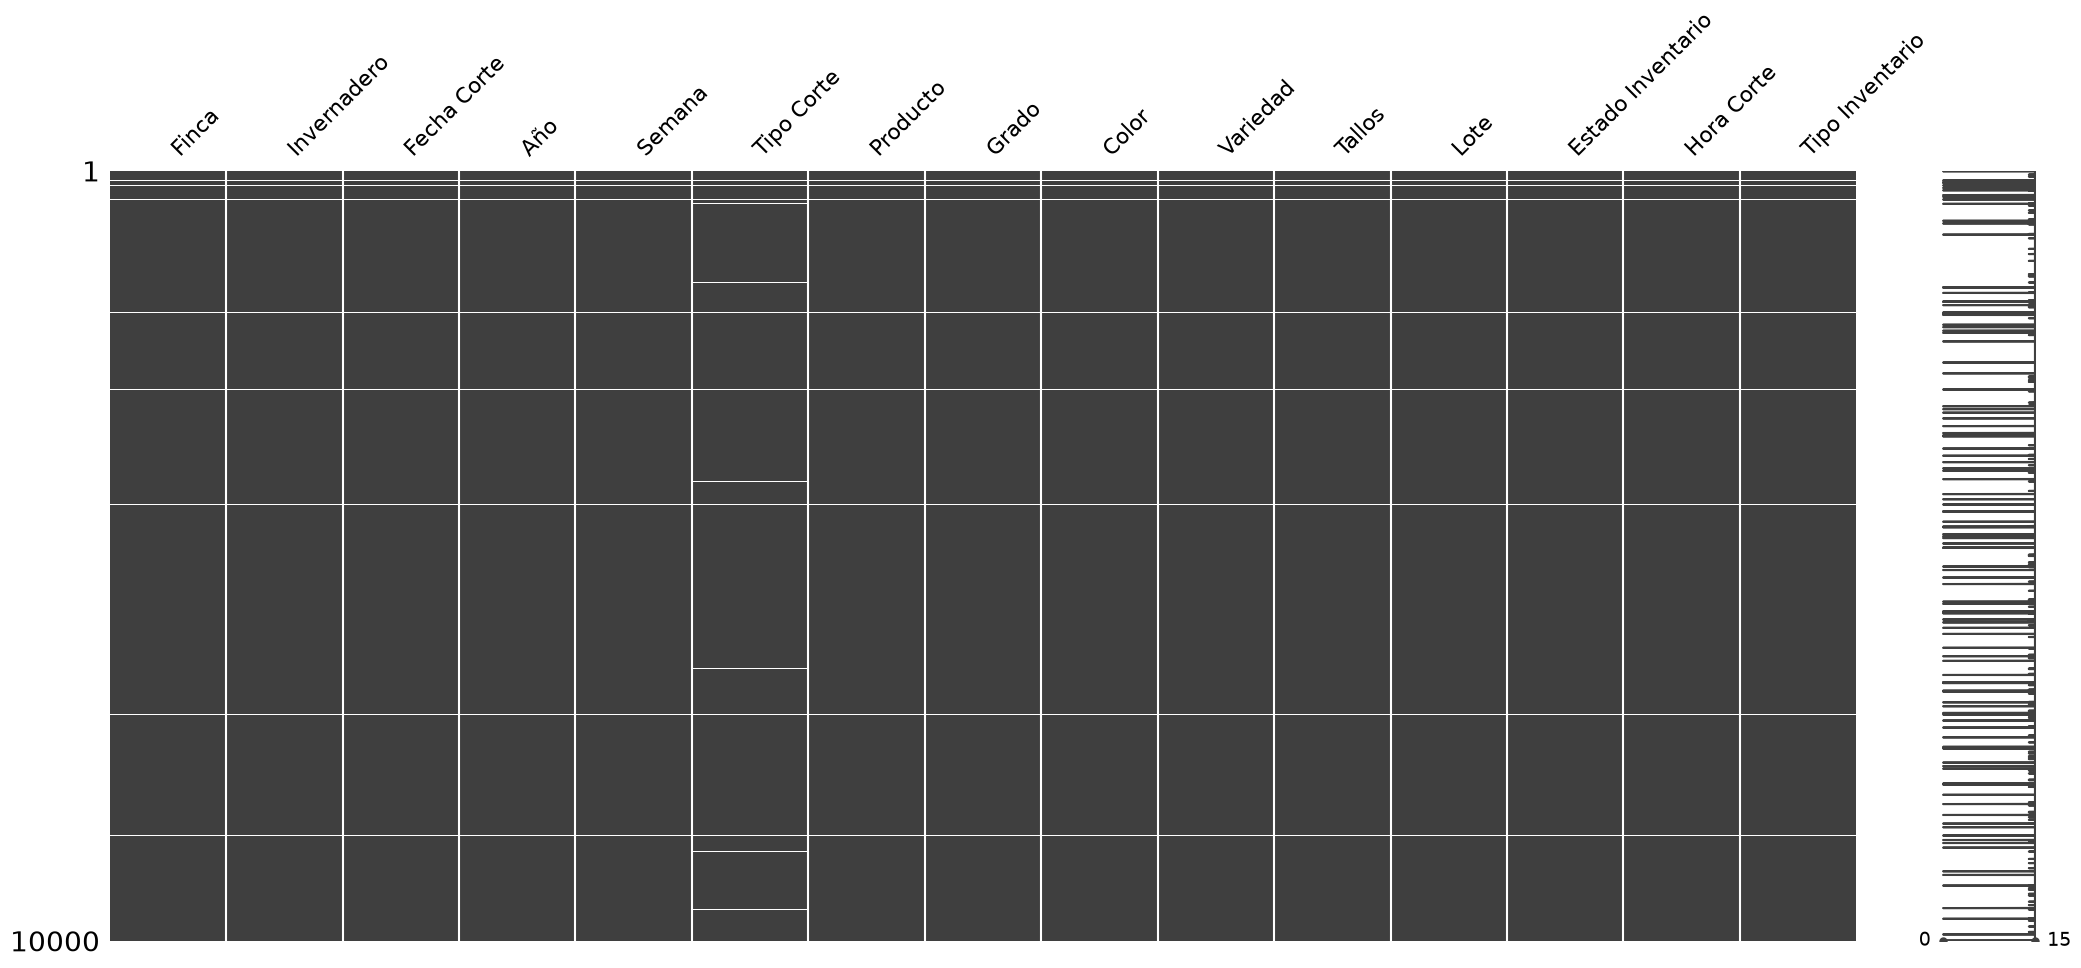

In [63]:
#Esto para ver si hay alguna matriz en la desaparición de datos, para ver si hay alguna correlación entre los datos que faltan y los que no faltan.

import missingno as msno
import matplotlib.pyplot as plt

# Visualización de datos faltantes
plt.figure(figsize=(14, 6))

msno.matrix(
    df_prod_clean.sample(
        n=min(10000, len(df_prod_clean)),
        random_state=42
    )
)

plt.show()

In [64]:
# Columnas clave para detectar filas realmente vacías
cols_clave = [
    "Finca", "Invernadero", "Fecha Corte", "Año", "Semana",
    "Tipo Corte", "Producto", "Grado", "Color", "Variedad",
    "Tallos", "Lote", "Estado Inventario", "Hora Corte", "Tipo Inventario"
]

# Detectar filas vacías
mask = df_prod_real[cols_clave].isna().all(axis=1)

# Crear bloques de vacíos consecutivos
grupo = mask.ne(mask.shift()).cumsum()

bloques = (
    df_prod_real[mask]
    .groupby(grupo[mask])
    .apply(lambda x: (x.index.min(), x.index.max()))
)

# Mostrar 5 filas antes y 5 después de los primeros 10 huecos
for inicio, fin in bloques.head(10):

    if inicio > 0 and fin < len(df_prod_real) - 1:

        print(f"\n{'='*100}")
        print(f"HUECO: {inicio} → {fin} | {fin-inicio+1} filas vacías")
        print(f"{'='*100}")

        print("\n⬆️  5 FILAS ANTES DEL HUECO")
        display(df_prod_real.loc[inicio-5:inicio-1])

        print("\n⬇️  5 FILAS DESPUÉS DEL HUECO")
        display(df_prod_real.loc[fin+1:fin+5])


HUECO: 94564 → 94593 | 30 filas vacías

⬆️  5 FILAS ANTES DEL HUECO


,Finca,Sector,Invernadero,Fecha Corte,Año,Semana,Tipo Corte,Producto,Grado,Color,Variedad,Tallos,Lote,Estado Inventario,Hora Corte,Inventario Físico,Reintegro,Tipo Inventario,Ajuste,Fecha Descarga
94559,GAITANA,Milton Pinzon,Bloque 32,2026-01-25,2026.0,4.0,Corte 2,Solomio,Granel,yellow,Blondfly,60.0,6899.0,Recepcion,11:57AM,NO,False,C,NaN,2025-01-22 07:36:19.770
94560,GAITANA,Milton Pinzon,Bloque 32,2026-01-25,2026.0,4.0,Corte 2,Solomio,Granel,yellow,Blondfly,60.0,6900.0,Recepcion,11:57AM,NO,False,C,NaN,2025-01-22 07:54:05.053
94561,GAITANA,Milton Pinzon,Bloque 32,2026-01-25,2026.0,4.0,Corte 2,Solomio,Granel,yellow,Blondfly,60.0,6901.0,Recepcion,11:57AM,NO,False,C,NaN,2025-01-26 10:43:25.160
94562,GAITANA,Milton Pinzon,Bloque 32,2026-01-25,2026.0,4.0,Corte 2,Solomio,Granel,yellow,Blondfly,60.0,6902.0,Recepcion,11:57AM,NO,False,C,NaN,2025-01-26 10:43:23.010
94563,GAITANA,Milton Pinzon,Bloque 32,2026-01-25,2026.0,4.0,Corte 2,Solomio,Granel,yellow,Blondfly,60.0,6903.0,Recepcion,11:57AM,NO,False,C,NaN,2025-01-25 11:29:11.533



⬇️  5 FILAS DESPUÉS DEL HUECO


,Finca,Sector,Invernadero,Fecha Corte,Año,Semana,Tipo Corte,Producto,Grado,Color,Variedad,Tallos,Lote,Estado Inventario,Hora Corte,Inventario Físico,Reintegro,Tipo Inventario,Ajuste,Fecha Descarga
94594,Arabella,Cristina Benavides,Bloque 11,2026-01-26,2026.0,5.0,Corte 2,Carnation,Granel,bicolor burgundy,Perfect,37.0,31414.0,Clasificación,11:41AM,NO,False,C,NaN,NaT
94595,Arabella,Cristina Benavides,Bloque 11,2026-01-26,2026.0,5.0,Corte 2,Carnation,Granel,bicolor burgundy,Perfect,80.0,31415.0,Clasificación,9:56AM,NO,False,C,NaN,2025-01-23 07:33:08.103
94596,Arabella,Cristina Benavides,Bloque 11,2026-01-26,2026.0,5.0,Corte 2,Carnation,Granel,bicolor burgundy,Perfect,20.0,31444.0,Clasificación,3:48PM,NO,False,C,NaN,2025-01-23 14:16:05.987
94597,Arabella,Cristina Benavides,Bloque 11,2026-01-26,2026.0,5.0,Corte 2,Carnation,Granel,bicolor burgundy,Perfect,80.0,31445.0,Clasificación,3:51PM,NO,False,C,NaN,2025-01-23 13:57:46.517
94598,Arabella,Cristina Benavides,Bloque 11,2026-01-26,2026.0,5.0,Corte 2,Carnation,Granel,bicolor pink,Antigua,48.0,62288.0,Clasificación,11:41AM,NO,False,C,NaN,2025-01-23 13:57:05.100


Bueno gracias a esto la decisión de diseño es eliminar las filas completamente vacias y hacer un reset de los índices

In [65]:
# Columnas que identifican un registro real de producción
cols_clave = [
    "Finca", "Invernadero", "Fecha Corte", "Año", "Semana",
    "Tipo Corte", "Producto", "Grado", "Color", "Variedad",
    "Tallos", "Lote", "Estado Inventario", "Hora Corte", "Tipo Inventario"
]

# Eliminar filas sin información de producción y reiniciar índice
df_prod_clean = (
    df_prod_clean
    .dropna(subset=cols_clave, how="all")
    .reset_index(drop=True)
)

print(f"Filas finales: {len(df_prod_clean):,}")

Filas finales: 918,049


<Figure size 1400x600 with 0 Axes>

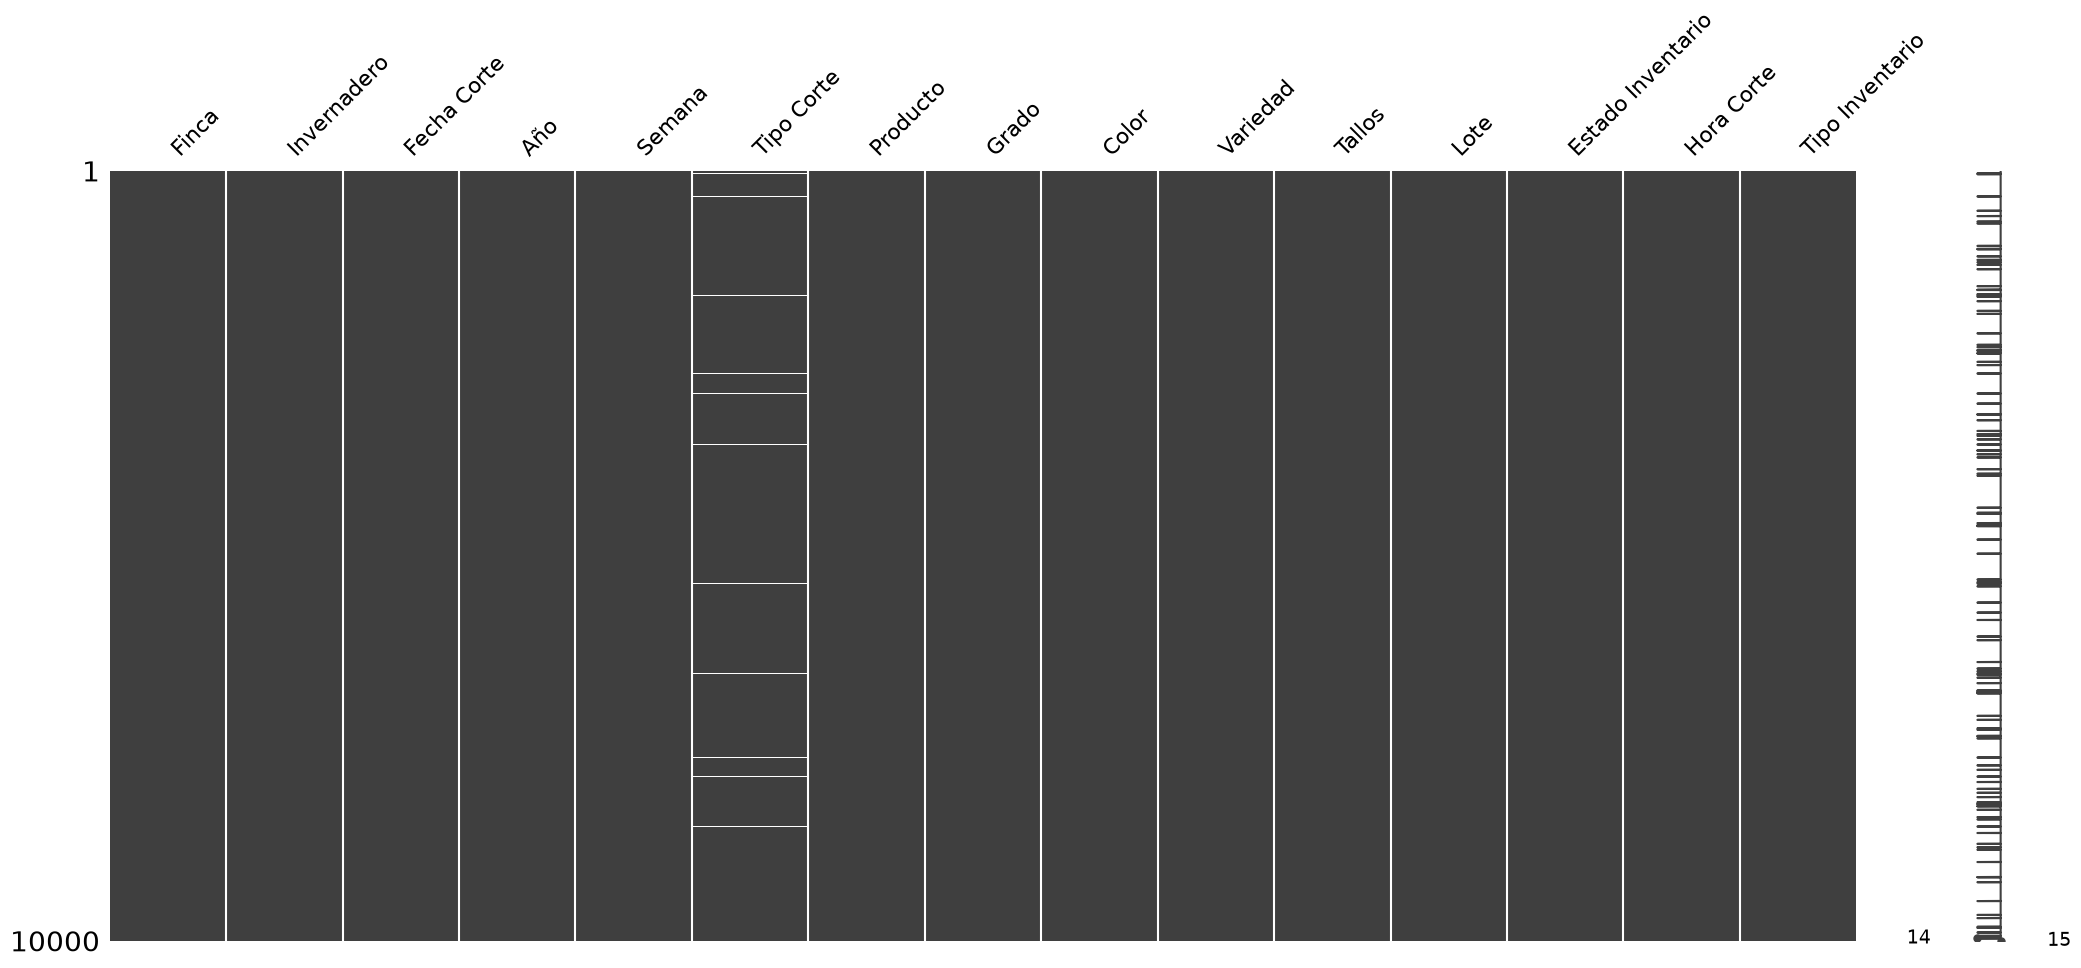

In [66]:
#Esto para ver si hay alguna matriz en la desaparición de datos, para ver si hay alguna correlación entre los datos que faltan y los que no faltan.

import missingno as msno
import matplotlib.pyplot as plt

# Visualización de datos faltantes
plt.figure(figsize=(14, 6))

msno.matrix(
    df_prod_clean.sample(
        n=min(10000, len(df_prod_clean)),
        random_state=42
    )
)

plt.show()

In [67]:
pd.DataFrame({
    "Faltantes": df_prod_clean.isna().sum(),
    "Porcentaje": (df_prod_clean.isna().mean() * 100).round(2)
}).query("Faltantes > 0")

,Faltantes,Porcentaje
Tipo Corte,11610,1.26


In [68]:
#Cómo es bien poquito la imputación de los datos lo vamos a hacer con la combinación PRODUCTO + COLOR + VARIEDAD... de la semana pasada, actual y una siguiente, cogiendo la mas frecuente... La idea es no perder nada de data.
# Semana calendario de cada registro
df_prod_clean["_semana"] = (
    df_prod_clean["Fecha Corte"]
    .dt.to_period("W-SUN")
    .dt.start_time
)

# Contar Tipo Corte por Producto + Color + Variedad + Semana
conteo = (
    df_prod_clean[df_prod_clean["Tipo Corte"].notna()]
    .groupby(
        ["Producto", "Color", "Variedad", "_semana", "Tipo Corte"]
    )
    .size()
    .reset_index(name="Cantidad")
)

# Para cada semana considerar: anterior, actual y siguiente
candidatos = pd.concat([
    conteo.assign(SemanaObjetivo=conteo["_semana"] - pd.Timedelta(days=7)),
    conteo.assign(SemanaObjetivo=conteo["_semana"]),
    conteo.assign(SemanaObjetivo=conteo["_semana"] + pd.Timedelta(days=7))
])

# Sumar frecuencias dentro de las 3 semanas
candidatos = (
    candidatos
    .groupby(
        ["Producto", "Color", "Variedad", "SemanaObjetivo", "Tipo Corte"],
        as_index=False
    )["Cantidad"]
    .sum()
)

# Escoger el Tipo Corte más frecuente
moda = (
    candidatos
    .sort_values("Cantidad", ascending=False)
    .drop_duplicates(
        ["Producto", "Color", "Variedad", "SemanaObjetivo"]
    )
    .set_index(
        ["Producto", "Color", "Variedad", "SemanaObjetivo"]
    )["Tipo Corte"]
)

# Imputar solamente los valores faltantes
mask = df_prod_clean["Tipo Corte"].isna()

claves = pd.MultiIndex.from_frame(
    df_prod_clean.loc[
        mask,
        ["Producto", "Color", "Variedad", "_semana"]
    ].rename(columns={"_semana": "SemanaObjetivo"})
)

df_prod_clean.loc[mask, "Tipo Corte"] = moda.reindex(claves).to_numpy()

# Eliminar columna auxiliar
df_prod_clean.drop(columns="_semana", inplace=True)

# Revisar cuántos faltantes quedaron
print("Faltantes restantes:", df_prod_clean["Tipo Corte"].isna().sum())


pd.DataFrame({
    "Faltantes": df_prod_clean.isna().sum(),
    "Porcentaje": (df_prod_clean.isna().mean() * 100).round(2)
}).query("Faltantes > 0")

Faltantes restantes: 0


,Faltantes,Porcentaje


In [69]:
df_prod_clean["Hora Corte"] = pd.to_datetime(
    df_prod_clean["Hora Corte"].astype(str).str.strip(),
    format="mixed",
    errors="coerce"
).dt.time

In [70]:
df_prod_clean["Hora Corte"].head(10)

0    09:53:00
1    10:17:00
2    09:54:00
3    09:54:00
4    09:54:00
5    09:54:00
6    09:54:00
7    09:54:00
8    09:54:00
9    09:53:00
Name: Hora Corte, dtype: object

In [71]:
df_prod_clean["Hora Corte"].isna().sum()

np.int64(0)

In [72]:
# Cambiar tipos de datos

df_prod_clean["Año"] = df_prod_clean["Año"].astype(int)
df_prod_clean["Semana"] = df_prod_clean["Semana"].astype(int)
df_prod_clean["Tallos"] = df_prod_clean["Tallos"].astype(int)
df_prod_clean["Lote"] = df_prod_clean["Lote"].astype(int)

# Hora Corte -> tipo hora
df_prod_clean["Hora Corte"] = pd.to_datetime(
    df_prod_clean["Hora Corte"].astype(str).str.strip(),
    format="mixed",
    errors="coerce"
).dt.time

# Revisar resultado
df_prod_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 918049 entries, 0 to 918048
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Finca              918049 non-null  str           
 1   Invernadero        918049 non-null  str           
 2   Fecha Corte        918049 non-null  datetime64[us]
 3   Año                918049 non-null  int64         
 4   Semana             918049 non-null  int64         
 5   Tipo Corte         918049 non-null  str           
 6   Producto           918049 non-null  str           
 7   Grado              918049 non-null  str           
 8   Color              918049 non-null  str           
 9   Variedad           918049 non-null  str           
 10  Tallos             918049 non-null  int64         
 11  Lote               918049 non-null  int64         
 12  Estado Inventario  918049 non-null  str           
 13  Hora Corte         918049 non-null  object        
 14 

In [73]:
df_prod_clean

,Finca,Invernadero,Fecha Corte,Año,Semana,Tipo Corte,Producto,Grado,Color,Variedad,Tallos,Lote,Estado Inventario,Hora Corte,Tipo Inventario
0,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,bicolor yellow,Spritz,80,62982,Recepcion,09:53:00,C
1,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,green,Prado Mint,80,30125,Recepcion,10:17:00,C
2,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,green,Prado Mint,80,30750,Recepcion,09:54:00,C
3,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,green,Prado Mint,80,30751,Clasificación,09:54:00,C
4,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,green,Prado Mint,80,31080,Clasificación,09:54:00,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
918044,GAITANA,Bloque 32,2026-08-29,2026,35,Corte 2,Solomio,Granel,hot pink,Imre,60,94186,Recepcion,10:01:00,C
918045,GAITANA,Bloque 32,2026-08-29,2026,35,Corte 2,Solomio,Granel,hot pink,Imre,60,94187,Recepcion,10:01:00,C
918046,GAITANA,Bloque 32,2026-08-29,2026,35,Corte 2,Solomio,Granel,white,Ard,60,46118,Recepcion,10:02:00,C
918047,GAITANA,Bloque 32,2026-08-29,2026,35,Corte 2,Solomio,Granel,white,Ard,60,46119,Recepcion,10:02:00,C


Ahora la limpieza de Estimados Horizonte 1 por aquello de que no se hizo arriba pero procesas las bases crudas se demora mucho

In [74]:
estimados_H1.info()

<class 'pandas.DataFrame'>
RangeIndex: 7282 entries, 0 to 7281
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   anio_inicial_estimado       7282 non-null   int64         
 1   semana_inicial_estimado     7282 non-null   int64         
 2   horizonte                   7282 non-null   int64         
 3   semanas_adelante            7282 non-null   int64         
 4   anio_objetivo               7282 non-null   int64         
 5   semana_objetivo             7282 non-null   int64         
 6   lunes_inicial_estimado      7282 non-null   datetime64[us]
 7   lunes_objetivo              7282 non-null   datetime64[us]
 8   archivo_origen              7282 non-null   str           
 9   semana_archivo              7282 non-null   int64         
 10  archivo_es_posterior        7282 non-null   bool          
 11  diferencia_semanas_archivo  7282 non-null   int64         
 12  COD

In [75]:
pd.DataFrame({
    "Faltantes": estimados_H1.isna().sum(),
    "Porcentaje": (estimados_H1.isna().mean() * 100).round(2)
}).query("Faltantes > 0")

,Faltantes,Porcentaje


no hay faltantes

ahora vamos a mirar si podemos borrar algunas cosas, pues digamos si hay columna que son igualitas

1. comparación de lunes_inicial_estimado y lunes objetivo



In [76]:
# Revisar si las fechas son diferentes
print(
    "Filas donde lunes_inicial_estimado != lunes_objetivo:",
    (estimados_H1["lunes_inicial_estimado"] != estimados_H1["lunes_objetivo"]).sum()
)

# Ver algunos ejemplos
estimados_H1.loc[
    estimados_H1["lunes_inicial_estimado"] != estimados_H1["lunes_objetivo"],
    ["lunes_inicial_estimado", "lunes_objetivo", "semanas_adelante", "horizonte"]
].head(10)

Filas donde lunes_inicial_estimado != lunes_objetivo: 0


,lunes_inicial_estimado,lunes_objetivo,semanas_adelante,horizonte


efectivamente se puede eliminar

In [77]:
estimados_H1.drop(
    columns=[
        "variedades validas",
        "anio_objetivo",
        "semana_objetivo",
        "lunes_inicial_estimado",
        "horizonte"
    ],
    inplace=True,
    errors="ignore"
)

estimados_H1.head()

,anio_inicial_estimado,semana_inicial_estimado,semanas_adelante,lunes_objetivo,archivo_origen,semana_archivo,archivo_es_posterior,diferencia_semanas_archivo,CODFINCA,PRODUCTO,COLOR,VARIEDAD,ESTI. EXPORTABLE,TIPO,CODIGO,AÑO,SEMANA
0,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,CABAÑA,Eryngium,Purple,Alpinium,14000,ESTIMADO,2026-1,2026,1
1,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,CABAÑA,Eryngium,Purple,Tropical Snow,800,ESTIMADO,2026-1,2026,1
2,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,GF,Carnation,Vintage,Antigua,2870,ESTIMADO,2026-1,2026,1
3,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,GF,Carnation,Peach,Apple Tea,3120,ESTIMADO,2026-1,2026,1
4,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,GF,Carnation,Orange,Arno,0,ESTIMADO,2026-1,2026,1


## Unión de estimados y producción real para captar diferencias y definición de metricas semana a semana

### 1. Preparar las dos bases

Se construyen nombres comparables, se corrige el año ISO desde `Fecha Corte`, se excluye La Cabaña y se eliminan estimados posteriores a la última semana con producción. No se reemplazan faltantes con cero.

In [123]:
import re
import unicodedata
from datetime import date

def limpiar_nombre(valor):
    if pd.isna(valor):
        return pd.NA
    texto = unicodedata.normalize("NFKD", str(valor)).encode("ascii", "ignore").decode()
    texto = re.sub(r"\s+", " ", texto.strip().upper())
    return texto if texto else pd.NA

def limpiar_finca(valor):
    nombre = limpiar_nombre(valor)
    mapa = {"GF": "GAITANA", "LA GAITANA": "GAITANA", "GAITANA": "GAITANA",
            "AR": "ARABELLA", "ARABELLA": "ARABELLA",
            "CABANA": "CABANA", "LA CABANA": "CABANA", "FINCA LA CABANA": "CABANA"}
    return mapa.get(nombre, nombre) if pd.notna(nombre) else pd.NA

est = estimados_H1.copy()
prod = df_prod_clean.copy()

if "horizonte" in est.columns:
    est = est[pd.to_numeric(est["horizonte"], errors="coerce").eq(1)].copy()

# Llaves del estimado.
est["anio"] = pd.to_numeric(est["AÑO"], errors="coerce").astype("Int64")
est["semana"] = pd.to_numeric(est["SEMANA"], errors="coerce").astype("Int64")
est["k_finca"] = est["CODFINCA"].map(limpiar_finca)
est["k_producto"] = est["PRODUCTO"].map(limpiar_nombre)
est["k_color"] = est["COLOR"].map(limpiar_nombre)
est["k_variedad"] = est["VARIEDAD"].map(limpiar_nombre)
est["tallos_estimados"] = pd.to_numeric(est["ESTI. EXPORTABLE"], errors="coerce")

# El año ISO se calcula desde la fecha: diciembre puede pertenecer a la semana 1 del año siguiente.
prod["fecha"] = pd.to_datetime(prod["Fecha Corte"], errors="coerce")
iso = prod["fecha"].dt.isocalendar()
prod["anio"] = iso.year.astype("Int64")
prod["semana"] = iso.week.astype("Int64")
prod["k_finca"] = prod["Finca"].map(limpiar_finca)
prod["k_producto"] = prod["Producto"].map(limpiar_nombre)
prod["k_color"] = prod["Color"].map(limpiar_nombre)
prod["k_variedad"] = prod["Variedad"].map(limpiar_nombre)
prod["tallos_reales"] = pd.to_numeric(prod["Tallos"], errors="coerce")

# Excluir La Cabaña en ambas fuentes.
cabana_est = est["k_finca"].eq("CABANA")
cabana_prod = prod["k_finca"].eq("CABANA")
control_cabana = pd.DataFrame({
    "fuente": ["estimado", "produccion"],
    "filas_excluidas": [cabana_est.sum(), cabana_prod.sum()],
    "tallos_excluidos": [est.loc[cabana_est, "tallos_estimados"].sum(),
                          prod.loc[cabana_prod, "tallos_reales"].sum()]
})
est = est[~cabana_est].copy()
prod = prod[~cabana_prod].copy()

# Corte en la última semana con producción real.
ultima_fecha_real = prod["fecha"].max().normalize()
iso_corte = ultima_fecha_real.isocalendar()
lunes_corte = pd.Timestamp(date.fromisocalendar(iso_corte.year, iso_corte.week, 1))
est["lunes_semana"] = pd.to_datetime(
    est["anio"].astype(str) + "-W" + est["semana"].astype(str).str.zfill(2) + "-1",
    format="%G-W%V-%u", errors="coerce"
)
estimados_fuera_corte = est[est["lunes_semana"] > lunes_corte].copy()
est = est[est["lunes_semana"] <= lunes_corte].copy()

display(control_cabana)
print(f"Última producción: {ultima_fecha_real.date()} | semana ISO {iso_corte.year}-S{iso_corte.week:02d}")
print(f"Filas estimadas posteriores excluidas: {len(estimados_fuera_corte):,}")

,fuente,filas_excluidas,tallos_excluidos
0,estimado,74,515830
1,produccion,0,0


Última producción: 2026-08-29 | semana ISO 2026-S35
Filas estimadas posteriores excluidas: 406


### 2. Revisar si las semanas de producción están completas

Se esperan registros de lunes a sábado. El domingo no se exige. Una fecha faltante se alerta, pero no se elimina porque podría ser festivo o un día legítimo sin producción.

In [124]:
def control_semana(grupo):
    anio = int(grupo.name[0]); semana = int(grupo.name[1])
    lunes = pd.Timestamp(date.fromisocalendar(anio, semana, 1))
    esperadas = {lunes + pd.Timedelta(days=i) for i in range(6)}
    observadas = set(grupo["fecha"].dropna().dt.normalize())
    faltantes = sorted(esperadas - observadas)
    return pd.Series({
        "dias_con_produccion": len(observadas),
        "dias_faltantes_lunes_sabado": len(faltantes),
        "fechas_faltantes": ", ".join(x.strftime("%Y-%m-%d") for x in faltantes),
        "estado_semana": "completa" if not faltantes else "revisar_festivo_o_faltante"
    })

control_semanas_produccion = (
    prod.groupby(["anio", "semana"], dropna=False)
    .apply(control_semana, include_groups=False)
    .reset_index()
)
display(control_semanas_produccion)

,anio,semana,dias_con_produccion,dias_faltantes_lunes_sabado,fechas_faltantes,estado_semana
0,2026,1,5,1,2026-01-01,revisar_festivo_o_faltante
1,2026,2,6,0,,completa
2,2026,3,7,0,,completa
3,2026,4,7,0,,completa
4,2026,5,6,0,,completa
5,2026,6,6,0,,completa
6,2026,7,6,0,,completa
7,2026,8,6,0,,completa
8,2026,9,6,0,,completa
9,2026,10,6,0,,completa


### 3. Primera unión: llave estricta

Cada fuente se suma primero por `año + semana + finca + producto + color + variedad`. Luego se hace una unión externa para distinguir coincidencias y pendientes.

In [125]:
llave_estricta = ["anio", "semana", "k_finca", "k_producto", "k_color", "k_variedad"]

est_agregado = est.groupby(llave_estricta, dropna=False, as_index=False).agg(
    tallos_estimados=("tallos_estimados", "sum")
)
prod_agregado = prod.groupby(llave_estricta, dropna=False, as_index=False).agg(
    tallos_reales=("tallos_reales", "sum")
)

union_estricta = est_agregado.merge(
    prod_agregado, on=llave_estricta, how="outer", indicator=True, validate="one_to_one"
)
union_estricta["estado"] = union_estricta["_merge"].map(
    {"both": "coincide", "left_only": "solo_estimado", "right_only": "solo_produccion"}
)
union_estricta.drop(columns="_merge", inplace=True)

coincidencias_estrictas = union_estricta[union_estricta["estado"].eq("coincide")].copy()
estimado_pendiente_tras_union_estricta = union_estricta[union_estricta["estado"].eq("solo_estimado")].copy()
produccion_pendiente_tras_union_estricta = union_estricta[union_estricta["estado"].eq("solo_produccion")].copy()

print("Coincidencias estrictas:", len(coincidencias_estrictas))
print("Solo estimado después de unión estricta:", len(estimado_pendiente_tras_union_estricta))
print("Solo producción después de unión estricta:", len(produccion_pendiente_tras_union_estricta))

Coincidencias estrictas: 5146
Solo estimado después de unión estricta: 1656
Solo producción después de unión estricta: 2210


### 4. Segunda unión: solamente el remanente, por variedad

Lo que no coincidió estrictamente se suma por `año + semana + variedad`. Las coincidencias recuperadas se añaden a las estrictas; lo demás queda como pendiente final.

In [126]:
llave_variedad = ["anio", "semana", "k_variedad"]

est_var = estimado_pendiente_tras_union_estricta.groupby(
    llave_variedad, dropna=False, as_index=False
).agg(tallos_estimados=("tallos_estimados", "sum"))

prod_var = produccion_pendiente_tras_union_estricta.groupby(
    llave_variedad, dropna=False, as_index=False
).agg(tallos_reales=("tallos_reales", "sum"))

union_por_variedad = est_var.merge(
    prod_var, on=llave_variedad, how="outer", indicator=True, validate="one_to_one"
)
recuperados_por_variedad = union_por_variedad[union_por_variedad["_merge"].eq("both")].copy()
estimado_pendiente_final = union_por_variedad[union_por_variedad["_merge"].eq("left_only")].copy()
produccion_pendiente_final = union_por_variedad[union_por_variedad["_merge"].eq("right_only")].copy()

columnas_comunes = ["anio", "semana", "k_variedad", "tallos_estimados", "tallos_reales"]
estrictas_final = coincidencias_estrictas[columnas_comunes].copy()
estrictas_final["nivel_union"] = "estricta"
recuperadas_final = recuperados_por_variedad[columnas_comunes].copy()
recuperadas_final["nivel_union"] = "solo_variedad"

base_comparable_h1 = pd.concat([estrictas_final, recuperadas_final], ignore_index=True)

print("Recuperadas por variedad:", len(recuperados_por_variedad))
print("Producción pendiente final:", len(produccion_pendiente_final))
print("Estimado pendiente final:", len(estimado_pendiente_final))

Recuperadas por variedad: 292
Producción pendiente final: 1753
Estimado pendiente final: 963


### 5. Ver claramente qué quedó pendiente

Estas son las dos tablas que deben revisarse para encontrar problemas de cobertura o nombres. La gráfica solo muestra el volumen semanal que sigue sin coincidencia.

,anio,semana,k_variedad,tallos_estimados,tallos_reales,_merge
0,2026,1,17MP12 FOR,NaN,204.0,right_only
1,2026,1,2019 R-43,NaN,153.0,right_only
2,2026,1,2020 B-23,NaN,69.0,right_only
3,2026,1,5417,NaN,151.0,right_only
4,2026,1,5523,NaN,85.0,right_only
5,2026,1,5752,NaN,119.0,right_only
6,2026,1,ACID GRAPE,NaN,15.0,right_only
7,2026,1,ALLEGRETTO,NaN,33.0,right_only
10,2026,1,BACARDI,NaN,125.0,right_only
11,2026,1,BLONDE,NaN,267.0,right_only


,anio,semana,k_variedad,tallos_estimados,tallos_reales,_merge
9,2026,1,BACARAT,0.0,NaN,left_only
12,2026,1,BONO,0.0,NaN,left_only
13,2026,1,BRISA,0.0,NaN,left_only
15,2026,1,BURGUNDY,0.0,NaN,left_only
28,2026,1,EMMA,0.0,NaN,left_only
35,2026,1,IBIS,0.0,NaN,left_only
42,2026,1,LADY GURIN,0.0,NaN,left_only
44,2026,1,LEGE MARRONE,0.0,NaN,left_only
45,2026,1,LUCY,0.0,NaN,left_only
48,2026,1,MERLETTO PURPLE,0.0,NaN,left_only


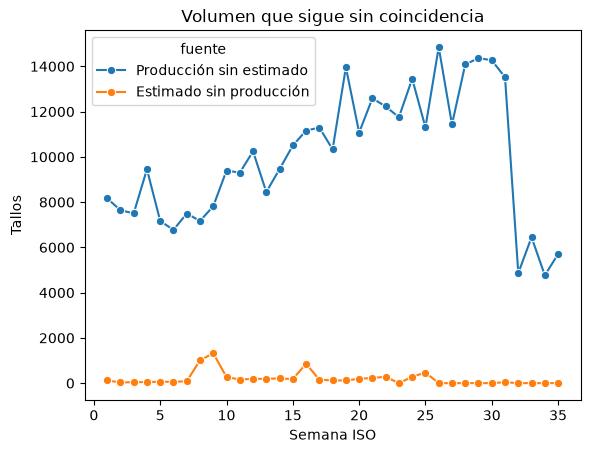

In [127]:
display(produccion_pendiente_final.head(30))
display(estimado_pendiente_final.head(30))

pendientes_grafica = pd.concat([
    produccion_pendiente_final.groupby("semana", as_index=False)["tallos_reales"].sum()
        .rename(columns={"tallos_reales": "tallos"}).assign(fuente="Producción sin estimado"),
    estimado_pendiente_final.groupby("semana", as_index=False)["tallos_estimados"].sum()
        .rename(columns={"tallos_estimados": "tallos"}).assign(fuente="Estimado sin producción")
])
sns.lineplot(data=pendientes_grafica, x="semana", y="tallos", hue="fuente", marker="o")
plt.title("Volumen que sigue sin coincidencia")
plt.xlabel("Semana ISO"); plt.ylabel("Tallos"); plt.show()

### 6. Métricas H1 semana a semana

El error se define como `estimado − real`: positivo es sobreestimación y negativo es subestimación. Se usan las coincidencias estrictas más las recuperadas por variedad.

In [128]:
base_comparable_h1["diferencia_tallos"] = (
    base_comparable_h1["tallos_estimados"] - base_comparable_h1["tallos_reales"]
)
base_comparable_h1["error_absoluto"] = base_comparable_h1["diferencia_tallos"].abs()

resumen_semanal_h1 = base_comparable_h1.groupby(["anio", "semana"], as_index=False).agg(
    tallos_estimados=("tallos_estimados", "sum"),
    tallos_reales=("tallos_reales", "sum"),
    diferencia_tallos=("diferencia_tallos", "sum"),
    error_absoluto_total=("error_absoluto", "sum"),
    comparaciones=("nivel_union", "size"),
    recuperadas_por_variedad=("nivel_union", lambda s: s.eq("solo_variedad").sum())
)
resumen_semanal_h1["WAPE_pct"] = (
    100 * resumen_semanal_h1["error_absoluto_total"]
    / resumen_semanal_h1["tallos_reales"].replace(0, np.nan)
)
resumen_semanal_h1 = resumen_semanal_h1.merge(
    control_semanas_produccion, on=["anio", "semana"], how="left", validate="one_to_one"
)
display(resumen_semanal_h1)

,anio,semana,tallos_estimados,tallos_reales,diferencia_tallos,error_absoluto_total,comparaciones,recuperadas_por_variedad,WAPE_pct,dias_con_produccion,dias_faltantes_lunes_sabado,fechas_faltantes,estado_semana
0,2026,1,1443790.0,1384944.0,58846.0,323952.0,165,7,23.390982,5,1,2026-01-01,revisar_festivo_o_faltante
1,2026,2,1632450.0,1395181.0,237269.0,411503.0,165,7,29.494596,6,0,,completa
2,2026,3,1696721.0,1678438.0,18283.0,336337.0,165,7,20.038691,7,0,,completa
3,2026,4,1852410.0,2131848.0,-279438.0,371952.0,165,7,17.447398,7,0,,completa
4,2026,5,1889840.0,1592229.0,297611.0,417093.0,165,8,26.195541,6,0,,completa
5,2026,6,1616660.0,2048902.0,-432242.0,483360.0,162,8,23.591172,6,0,,completa
6,2026,7,1686150.0,2015075.0,-328925.0,434289.0,160,8,21.552002,6,0,,completa
7,2026,8,1720180.0,1726012.0,-5832.0,249224.0,160,8,14.439297,6,0,,completa
8,2026,9,1619330.0,1900283.0,-280953.0,336345.0,158,8,17.699732,6,0,,completa
9,2026,10,1694220.0,1970568.0,-276348.0,391022.0,157,8,19.843111,6,0,,completa
